# Naive Bayes Demonstration In Python
#### Marketing Campaing Response Model
   

## Background: 
The large skin-clinic in the city of “XXX” offers variety of products and services to customers. The marketing campaign was launched for introducing a new product.

The data shows response to the marketing campaign alongwith demographic and transaction data of customers.

The objective is to develop a predictive model which can be implemented for the next campaign

## Dataset Description :

| Column Name     | Description                                                                                  |
|-----------------|----------------------------------------------------------------------------------------------|
| Custid          | Unique Customer Identification Code                                                          |
| Age             | Age Group (1: <32 years, 2: 32–48 years, 3: >48 years)                                      |
| Gender          | Gender of Customer (1: Female, 2: Male)                                                     |
| MS              | Marital Status (1: Not Married, 2: Married)                                                 |
| Response        | Customer Campaign Response (1: Responded, 0: Not Responded)                                 |
| Pre_Month       | Purchase Status in Previous Month (1: Purchased, 2: No Purchase)                            |
| N_Products      | Number of Unique Products Purchased in One Year                                             |
| N_Service       | Number of Unique Services Purchased in One Year                                             |
| BillAmt_1       | Bill Amount (USD) for Purchase Transaction 1                                                |
| BillAmt_2       | Bill Amount (USD) for Purchase Transaction 2                                                |
| BillAmt_3       | Bill Amount (USD) for Purchase Transaction 3                                                |


### 1. Import Libraries

In [1]:
import pandas as pd  
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import cohen_kappa_score
import warnings
warnings.filterwarnings('ignore')

### 2. Import Data

In [25]:
purchase_data1 = pd.read_csv('Purchase Data 1.csv')
purchase_data2 = pd.read_csv('Purchase Data 2.csv')
response_data = pd.read_csv('Response Data.csv')

purchase_data1.head()

,Custid,Pre_Month,N_Products,N_Service
0,1,2,15,24
1,2,1,22,29
2,3,1,17,21
3,4,2,18,22
4,5,1,31,35


In [26]:
purchase_data2.head()

,Custid,BillAmt_1,BillAmt_2,BillAmt_3
0,1,12.34,13.26,5.88
1,2,18.65,2.12,5.13
2,3,7.22,3.31,3.65
3,4,6.15,2.95,2.34
4,5,20.64,2.67,4.07


In [27]:
response_data.head()

,Custid,Age,Gender,MS,Response
0,1,2,1,2,1
1,2,2,2,1,0
2,3,1,1,2,0
3,4,2,1,1,0
4,5,2,2,1,0


In [28]:
#Merging above 3 datasets using Custid column
masterdata=pd.merge(response_data,purchase_data1,how='left',on = 'Custid')
masterdata=pd.merge(masterdata,purchase_data2,how='left',on = 'Custid')
masterdata.head()

,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3
0,1,2,1,2,1,2,15,24,12.34,13.26,5.88
1,2,2,2,1,0,1,22,29,18.65,2.12,5.13
2,3,1,1,2,0,1,17,21,7.22,3.31,3.65
3,4,2,1,1,0,2,18,22,6.15,2.95,2.34
4,5,2,2,1,0,1,31,35,20.64,2.67,4.07


In [3]:
masterdata.dtypes

Custid          int64
Age             int64
Gender          int64
MS              int64
Response        int64
Pre_Month       int64
N_Products      int64
N_Service       int64
BillAmt_1     float64
BillAmt_2     float64
BillAmt_3     float64
dtype: object

### 3. Variable Type Conversion: Integer → Category

In [30]:
masterdata['Age'] = masterdata['Age'].astype('category')
masterdata['Gender'] = masterdata['Gender'].astype('category')
masterdata['MS'] = masterdata['MS'].astype('category')
masterdata['Pre_Month'] = masterdata['Pre_Month'].astype('category')

### 4. Perform Feature Engineering (Recoding Variables)

As part of feature engineering, we will recode a continuous numerical variable into three meaningful buckets (Low, Medium, High) to simplify the distribution and make the model interpret the pattern more effectively

In [31]:
#Recoding Numerical variables to Categorical
# List of variables to bucketize
bucket_vars = ['BillAmt_1', 'BillAmt_2', 'BillAmt_3',
               'N_Products', 'N_Service']

# Apply qcut in a loop
for var in bucket_vars:
    masterdata[f'{var}_Bucket'] = pd.qcut(
        masterdata[var],
        q=3,
        labels=['Low', 'Medium', 'High']
    )

masterdata.head()

,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3,BillAmt_1_Bucket,BillAmt_2_Bucket,BillAmt_3_Bucket,N_Products_Bucket,N_Service_Bucket
0,1,2,1,2,1,2,15,24,12.34,13.26,5.88,Medium,High,High,Low,Low
1,2,2,2,1,0,1,22,29,18.65,2.12,5.13,High,Medium,High,Low,Medium
2,3,1,1,2,0,1,17,21,7.22,3.31,3.65,Low,High,Medium,Low,Low
3,4,2,1,1,0,2,18,22,6.15,2.95,2.34,Low,Medium,Low,Low,Low
4,5,2,2,1,0,1,31,35,20.64,2.67,4.07,High,Medium,High,High,High


### 5. Estimating Campaign Response Rate : Overall


In [32]:
# Overall response rate
overall_response_rate = masterdata['Response'].mean() * 100
print(f"Overall Campaign Response Rate: {overall_response_rate:.2f}%")

Overall Campaign Response Rate: 13.23%


### 6. Data Pre-processing

### a. Create dummies (for categorical variables)

In [34]:
categorical_vars = ['Age', 'Gender', 'MS', 'Pre_Month','BillAmt_1_Bucket',
       'BillAmt_2_Bucket', 'BillAmt_3_Bucket','N_Products_Bucket',
       'N_Service_Bucket']
dummies = pd.get_dummies(masterdata[categorical_vars], drop_first=True)

# Append (concatenate) dummy columns to masterdata
masterdata = pd.concat([masterdata, dummies], axis=1)
masterdata.head()

,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,...,BillAmt_1_Bucket_Medium,BillAmt_1_Bucket_High,BillAmt_2_Bucket_Medium,BillAmt_2_Bucket_High,BillAmt_3_Bucket_Medium,BillAmt_3_Bucket_High,N_Products_Bucket_Medium,N_Products_Bucket_High,N_Service_Bucket_Medium,N_Service_Bucket_High
0,1,2,1,2,1,2,15,24,12.34,13.26,...,True,False,False,True,False,True,False,False,False,False
1,2,2,2,1,0,1,22,29,18.65,2.12,...,False,True,True,False,False,True,False,False,True,False
2,3,1,1,2,0,1,17,21,7.22,3.31,...,False,False,False,True,True,False,False,False,False,False
3,4,2,1,1,0,2,18,22,6.15,2.95,...,False,False,True,False,False,False,False,False,False,False
4,5,2,2,1,0,1,31,35,20.64,2.67,...,False,True,True,False,False,True,False,True,False,True


### b.  Split Data Into Train & Test

In [35]:
X_temp = masterdata.drop(columns=['Response','Custid'])
y = masterdata['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y, test_size=0.3, random_state=42, stratify=y
)

# Display shapes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
print("\nTrain Response Distribution:\n", y_train.value_counts(normalize=True)*100)
print("\nTest Response Distribution:\n", y_test.value_counts(normalize=True)*100)

Training Data Shape: (4893, 44)
Testing Data Shape: (2097, 44)

Train Response Distribution:
 Response
0    86.756591
1    13.243409
Name: proportion, dtype: float64

Test Response Distribution:
 Response
0    86.790653
1    13.209347
Name: proportion, dtype: float64


### 7. Model Development

### a.  Model A: Naive Bayes for Numeric Variables
Gaussian Naive Bayes can handle numeric + categorical (via dummies), but treats all features as continuous.


In [9]:
model_A_vars = ['N_Products', 'N_Service', 'BillAmt_1',
       'BillAmt_2', 'BillAmt_3', 'Age_2', 'Age_3', 'Gender_2', 'MS_2',
       'Pre_Month_2']

In [10]:
X_train_A = X_train[model_A_vars]
X_test_A  = X_test[model_A_vars]

In [11]:

gnb = GaussianNB()
gnb.fit(X_train_A, y_train)

GaussianNB()

### b. Model A Evaluation : ROC Curve for Train and Test Data

In [12]:
y_train_pred_prob = gnb.predict_proba(X_train_A)[:,1]
y_test_pred_prob = gnb.predict_proba(X_test_A)[:,1]
from sklearn.metrics import roc_auc_score

train_auc = roc_auc_score(y_train, y_train_pred_prob)
test_auc = roc_auc_score(y_test, y_test_pred_prob)

print("Train AUC Score:", round(train_auc,4))
print("Test AUC Score:", round(test_auc,4))


Train AUC Score: 0.7459
Test AUC Score: 0.7314


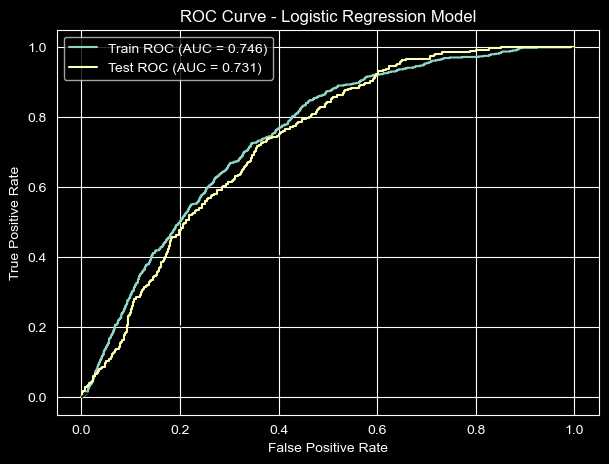

In [13]:
# ROC curve values
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_auc:.3f})')

# Reference diagonal
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Model")
plt.legend()
plt.grid(True)
plt.show()


###  c.  Model B:Naive Bayes For Categorical Variable
Multinomial Naive Bayes is designed for count-based or frequency-like features and is commonly used for categorical or text-based data.


In [14]:
model_B_vars = ['Age_2', 'Age_3', 'Gender_2', 'MS_2',
       'Pre_Month_2', 'BillAmt_1_Bucket_Medium', 'BillAmt_1_Bucket_High',
       'BillAmt_2_Bucket_Medium', 'BillAmt_2_Bucket_High',
       'BillAmt_3_Bucket_Medium', 'BillAmt_3_Bucket_High','N_Products_Bucket_Medium', 'N_Products_Bucket_High',
       'N_Service_Bucket_Medium', 'N_Service_Bucket_High']

In [15]:
X_train_B = X_train[model_B_vars]
X_test_B  = X_test[model_B_vars]
# Display shapes
print("Training Data Shape:", X_train_B.shape)
print("Testing Data Shape:", X_test_B.shape)
print("\nTrain Response Distribution:\n", y_train.value_counts(normalize=True)*100)
print("\nTest Response Distribution:\n", y_test.value_counts(normalize=True)*100)


Training Data Shape: (4893, 15)
Testing Data Shape: (2097, 15)

Train Response Distribution:
 Response
0    86.756591
1    13.243409
Name: proportion, dtype: float64

Test Response Distribution:
 Response
0    86.790653
1    13.209347
Name: proportion, dtype: float64


In [36]:
mnb = MultinomialNB()
mnb.fit(X_train_B, y_train)

MultinomialNB()

### d. Model B Evaluation : ROC Curve For Train and Test Data

In [17]:
y_train_pred_prob_b = mnb.predict_proba(X_train_B)[:,1]
y_test_pred_prob_b = mnb.predict_proba(X_test_B)[:,1]
from sklearn.metrics import roc_auc_score

train_auc_b = roc_auc_score(y_train, y_train_pred_prob_b)
test_auc_b = roc_auc_score(y_test, y_test_pred_prob_b)

print("Train AUC Score:", round(train_auc_b,4))
print("Test AUC Score:", round(test_auc_b,4))


Train AUC Score: 0.6779
Test AUC Score: 0.6568


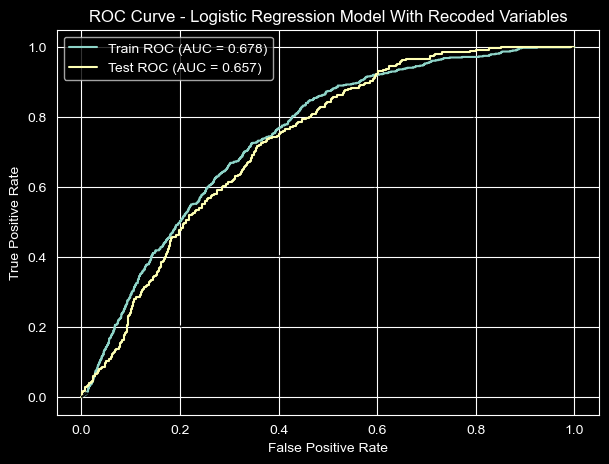

In [18]:
# ROC curve values
fpr_train_b, tpr_train_b, _ = roc_curve(y_train, y_train_pred_prob_b)
fpr_test_b, tpr_test_b, _ = roc_curve(y_test, y_test_pred_prob_b)

plt.figure(figsize=(7,5))
plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc_b:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_auc_b:.3f})')

# Reference diagonal
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression Model With Recoded Variables")
plt.legend()
plt.grid(True)
plt.show()

### 8. Performance Comparison                                           


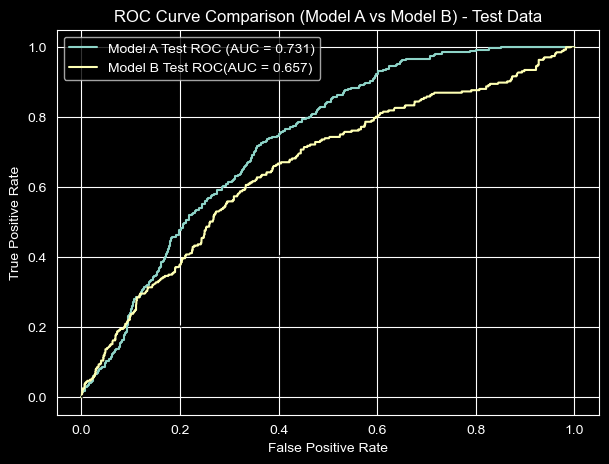

In [19]:
# ---------- Plot Combined ROC ----------
plt.figure(figsize=(7,5))

#plt.plot(fpr_test, tpr_test, label=f'Model A (AUC = {test_auc:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Model A Test ROC (AUC = {test_auc:.3f})')

plt.plot(fpr_test_b, tpr_test_b, label=f'Model B Test ROC(AUC = {test_auc_b:.3f})')

# Reference line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Model A vs Model B) - Test Data")
plt.legend()
plt.grid(True)
plt.show()

### Model A emerges as the better-performing model, as it achieves the highest Test AUC. Therefore, we will proceed to determine the optimal classification threshold for Model A.

### 9. Find Optimum Threshold for classification by maximizing sensitivity + specificity 


In [37]:
fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_prob)
i = np.arange(len(tpr))

# Build ROC dataframe
roc = pd.DataFrame({
    'fpr'        : pd.Series(fpr, index=i),
    'tpr'        : pd.Series(tpr, index=i),
    '1-fpr'      : pd.Series(1-fpr, index=i),
    'tf'         : pd.Series(tpr - (1-fpr), index=i),  # Youden's J statistic
    'thresholds' : pd.Series(thresholds, index=i)
})

# Find optimal threshold (maximizing sensitivity-specificity difference)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = roc.iloc[optimal_idx]['thresholds']

print("Optimal Threshold:", round(optimal_threshold,4))


Optimal Threshold: 0.1282


### a. Apply Threshold — Train Confusion Matrix & Classification Report


In [21]:
# Predict based on threshold
y_train_pred_opt = (y_train_pred_prob >= optimal_threshold).astype(int)

print("\nTRAIN CONFUSION MATRIX:")
print(confusion_matrix(y_train, y_train_pred_opt))

print("\nTRAIN CLASSIFICATION REPORT:")
print(classification_report(y_train, y_train_pred_opt))



TRAIN CONFUSION MATRIX:
[[2280 1965]
 [  98  550]]

TRAIN CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.96      0.54      0.69      4245
           1       0.22      0.85      0.35       648

    accuracy                           0.58      4893
   macro avg       0.59      0.69      0.52      4893
weighted avg       0.86      0.58      0.64      4893



### b.  Apply Threshold — Test Confusion Matrix  & Classification Report

In [22]:
y_test_pred_opt = (y_test_pred_prob >= optimal_threshold).astype(int)

print("\nTEST CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_test_pred_opt))

print("\nTEST CLASSIFICATION REPORT:")
print(classification_report(y_test, y_test_pred_opt))



TEST CONFUSION MATRIX:
[[986 834]
 [ 56 221]]

TEST CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.95      0.54      0.69      1820
           1       0.21      0.80      0.33       277

    accuracy                           0.58      2097
   macro avg       0.58      0.67      0.51      2097
weighted avg       0.85      0.58      0.64      2097



###  10. Model Validation : K-Fold Cross Validation Method

In [23]:
X = masterdata[model_A_vars]
y = masterdata['Response']

predicted_prob = cross_val_predict(gnb, X, y, cv=4, method='predict_proba') 
threshold=optimal_threshold
predicted = predicted_prob[:,1]
predicted_class1=np.zeros(predicted.shape)
predicted_class1[predicted>threshold]=1

print(classification_report(y,predicted_class1))

              precision    recall  f1-score   support

           0       0.95      0.53      0.68      6065
           1       0.21      0.82      0.34       925

    accuracy                           0.57      6990
   macro avg       0.58      0.68      0.51      6990
weighted avg       0.85      0.57      0.64      6990

